# Case Studies in Machine Learning with Strain Gages
### *Modern Strain Gage Technology* — Companion Notebook

Three worked case studies that carry the toolkit of Part 9 — anomaly detection, sequential change detection, and supervised classification — into the messy, practical world of structural health monitoring.

*Companion notebook to Chapter 59 — Case Studies in Machine Learning with Strain Gages.*

The earlier chapters in Part 9 established the toolkit: feature extraction, linear models, random forests, neural networks, anomaly detection, sequential learning. Case studies put that toolkit in contact with the messy, practical world of structural health monitoring — where classes are not neatly balanced, anomalies are not cleanly separated from normal data, and failure modes are not always known in advance.

Three case studies are presented here, each addressing a distinct problem archetype. The first asks the most basic question: *is this structure behaving normally?* — unsupervised anomaly detection from a four-channel strain array. The second asks the temporal question: *how early can we detect a growing crack, and how confident should we be?* — progressive damage tracking using the **CUSUM** change detector of Chapter 56 over a sequence of load cycles. The third asks the diagnostic question: *given that something is wrong, what kind of wrong is it?* — classifying four distinct composite damage signatures (healthy, matrix cracking, delamination, fiber breakage) using a random forest trained on labeled strain patterns.

Each case study is self-contained: it generates data from a realistic physical scenario, trains on it, and evaluates with metrics appropriate to the task. Together they trace the path from raw strain signal to structural intelligence — which is the arc this entire book has been building toward.

**This notebook demonstrates:**
1. Anomaly detection from strain pattern shifts — Isolation Forest with ROC-curve evaluation
2. Progressive damage tracking — detecting a growing crack early with a CUSUM statistic over load cycles
3. Four-class composite damage classification — distinguishing matrix cracking, delamination, and fiber-breakage signatures

> **A note on the data.** Every dataset below is *synthetic*, generated from physically motivated strain distributions so the notebook runs anywhere with no external files. The figures illustrate what each method *shows* — an ROC curve, a CUSUM trace, a confusion matrix — they are not reproductions of a specific published experiment. All randomness is seeded, so the results are identical on every run.

In [1]:
# !pip install numpy matplotlib scikit-learn
# ── Imports and shared setup ─────────────────────────────────────────────────
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# One random_state for every estimator + a base seed for the synthetic data,
# so the whole notebook is reproducible run-to-run.
RANDOM_STATE = 0

# All figures are written here, under the chapter's media folder.
OUT_DIR = Path("../src/media/ch59")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Anomaly Detection from a Four-Channel Strain Array

The scenario: a steel structure is monitored by four strain gages placed at critical locations. During normal operation the four channels are correlated in a characteristic pattern — load applied at a specific point produces a specific combination of strains at each gage, governed by structural mechanics. Damage redistributes load and changes that pattern. The anomaly detector must learn the normal pattern and flag deviations.

Isolation Forest is trained exclusively on healthy data (500 samples from the baseline distribution), then scored on a mixed dataset containing 80 damaged samples. The damaged population has a shifted mean (crack redistributes load into channels 1 and 2) and elevated covariance (crack-induced slip introduces additional variability). Neither the shift nor the elevated variance is known to the detector — it must discover the anomalies from the pattern alone.

The three-panel figure shows the separation in the gage-1 vs. gage-2 plane (healthy cloud vs. scattered damaged points), the anomaly score distributions (overlap region is where false alarms and missed detections occur), and the ROC curve quantifying the trade-off between detection rate and false alarm rate at every possible threshold. The AUC — area under the ROC curve — is the primary summary metric: AUC = 1.0 means perfect separation; AUC = 0.5 means the detector is no better than random.

Isolation Forest  Precision=0.504  Recall=0.875  AUC=0.950
Detected 70/80 damaged states, 69 false alarms


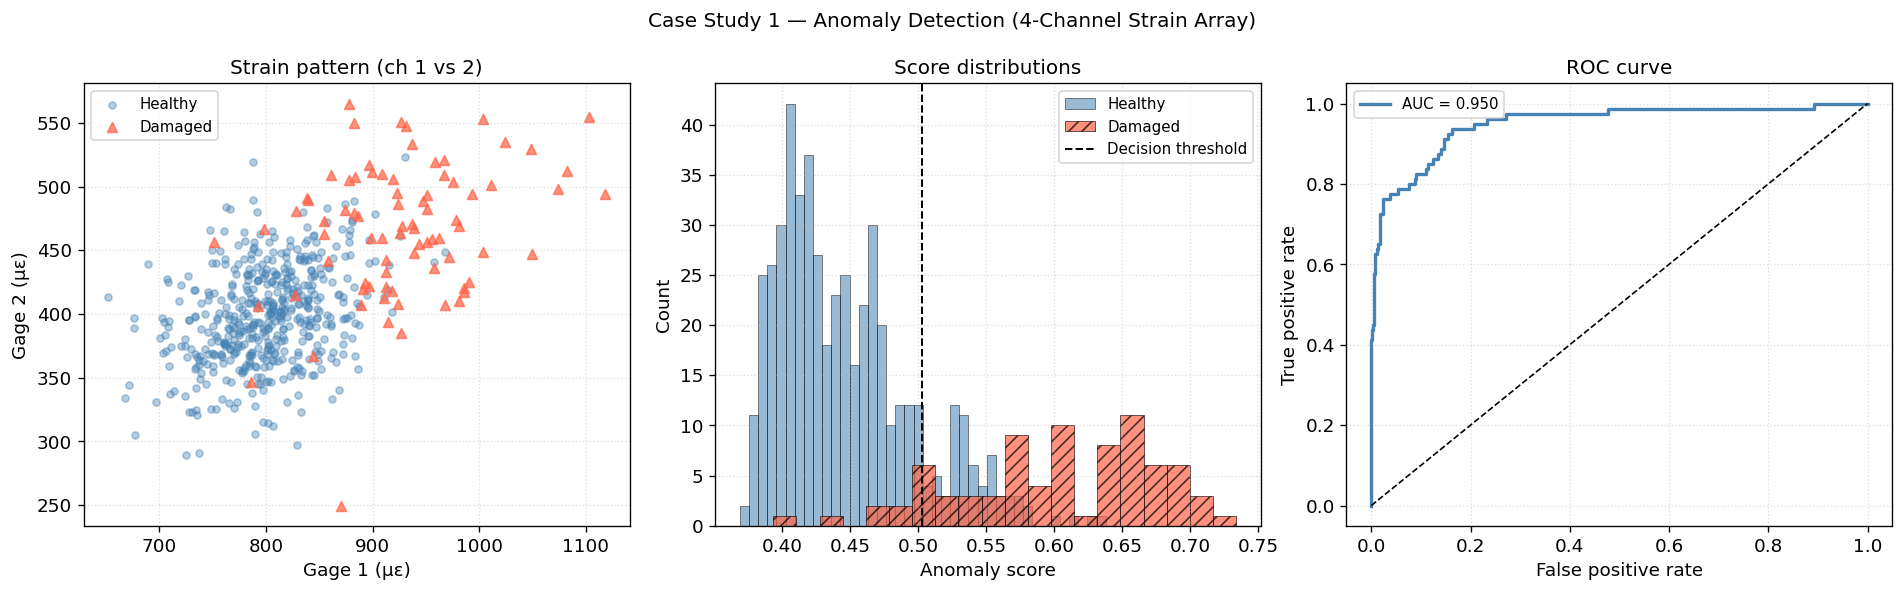

In [2]:
# ── Case Study 1: Anomaly Detection ─────────────────────────────────────────
np.random.seed(42)

N_HEALTHY, N_DAMAGED = 500, 80
N_ESTIMATORS = 200          # trees per Isolation Forest
# Expected fraction of anomalies in the monitored stream; sets the predict() cutoff.
CONTAMINATION = N_DAMAGED / (N_HEALTHY + N_DAMAGED)

# 4-channel strain array: [gage1, gage2, gage3, gage4] in µε.
# Covariances are hand-built so the channels are physically correlated
# (load at one point strains several gages together).
cov_healthy = np.array([
    [2500,  800, -600,  200],
    [ 800, 1600, -400,  100],
    [-600, -400, 2000, -300],
    [ 200,  100, -300,  400],
])
# Damaged: ch1 & ch2 mean-shift + elevated variance (a crack redistributes load).
cov_damaged = np.array([
    [5000, 1200, -900,  300],
    [1200, 3500, -600,  150],
    [-900, -600, 2200, -300],
    [ 300,  150, -300,  600],
])
mean_healthy = [800, 400, -300, 100]
mean_damaged = [920, 470, -260, 130]

X_h = np.random.multivariate_normal(mean_healthy, cov_healthy, N_HEALTHY)
X_d = np.random.multivariate_normal(mean_damaged, cov_damaged, N_DAMAGED)
X_all = np.vstack([X_h, X_d])
y_true = np.array([0] * N_HEALTHY + [1] * N_DAMAGED)   # 0 = healthy, 1 = damaged

# Fit the scaler on HEALTHY data only — the detector never sees damaged
# statistics at training time, so normalization must not leak them either.
sc = StandardScaler().fit(X_h)
Xs_h = sc.transform(X_h)
Xs_all = sc.transform(X_all)

# Train exclusively on healthy data, then score the full mixed stream.
iso = IsolationForest(contamination=CONTAMINATION,
                      n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE)
iso.fit(Xs_h)

scores = -iso.score_samples(Xs_all)   # higher = more anomalous
pred = iso.predict(Xs_all)            # +1 = normal, -1 = anomaly

TP = np.sum((pred == -1) & (y_true == 1))
FP = np.sum((pred == -1) & (y_true == 0))
precision = TP / (TP + FP) if TP + FP else 0.0
recall = TP / N_DAMAGED

fpr, tpr, _ = roc_curve(y_true, scores)
roc_auc = auc(fpr, tpr)

print(f"Isolation Forest  Precision={precision:.3f}  Recall={recall:.3f}  AUC={roc_auc:.3f}")
print(f"Detected {TP}/{N_DAMAGED} damaged states, {FP} false alarms")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Case Study 1 — Anomaly Detection (4-Channel Strain Array)', fontsize=12)

# Scatter: ch1 vs ch2
ax = axes[0]
ax.scatter(X_h[:, 0], X_h[:, 1], s=18, alpha=0.4, color='steelblue', label='Healthy')
ax.scatter(X_d[:, 0], X_d[:, 1], s=35, alpha=0.7, color='tomato', marker='^', label='Damaged')
ax.set_xlabel('Gage 1 (µε)'); ax.set_ylabel('Gage 2 (µε)')
ax.set_title('Strain pattern (ch 1 vs 2)')
ax.legend(fontsize=9); ax.grid(True, linestyle=':', alpha=0.4)

# Anomaly score distributions
ax = axes[1]
ax.hist(scores[y_true == 0], bins=40, alpha=0.55, color='steelblue',
        edgecolor='black', linewidth=0.5, label='Healthy')
ax.hist(scores[y_true == 1], bins=20, alpha=0.7, color='tomato',
        edgecolor='black', linewidth=0.5, hatch='///', label='Damaged')
thresh = np.percentile(scores[y_true == 0], 100 * (1 - CONTAMINATION))
ax.axvline(thresh, color='black', lw=1.2, ls='--', label='Decision threshold')
ax.set_xlabel('Anomaly score'); ax.set_ylabel('Count')
ax.set_title('Score distributions')
ax.legend(fontsize=9); ax.grid(True, linestyle=':', alpha=0.4)

# ROC curve
ax = axes[2]
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.3f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('ROC curve')
ax.legend(fontsize=9); ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig59_nb1_anomaly_detection_case.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 2 — Progressive Damage Tracking: How Early Can We Detect a Growing Crack?

A fatigue crack does not appear instantaneously — it grows cycle by cycle, following something close to Paris's law: slow initiation, then accelerating growth toward fracture. The question for a monitoring system is not "is there damage?" (a binary yes/no) but "*when* does the damage become detectable?" The honest answer is that a per-sample threshold — one that fires when a single reading looks anomalous — is a poor early detector of *gradual* change. Each individual reading early in the crack's life is only slightly abnormal, well inside the noise, so a threshold set high enough to avoid false alarms will not trip until the damage is already severe.

The fix is to **accumulate evidence over time** rather than judging each reading alone. That is exactly what the **CUSUM** (cumulative sum) statistic of Chapter 56 does. Its update rule, Eq. 56.2, is:

$$S_t = \max\!\left(0,\; S_{t-1} + (a_t - \mu_0) - k\right)$$

In plain English: at each step, add the current anomaly score's excess above the baseline mean $\mu_0$ (minus an allowance $k$ that absorbs normal noise) to a running total; if the process is healthy the total drains back to zero, but if the anomaly score has genuinely shifted upward, the small excesses compound until the total crosses an alarm threshold $h$. Because each small increment contributes to the running sum rather than being tested in isolation, CUSUM detects a slow drift *sooner* than a per-sample threshold can.

The simulation grows a crack from zero to full severity over 2000 load cycles. Every 20 cycles it draws a block of four-channel strain readings from the current (partially shifted) distribution and scores them with the Isolation Forest already trained on healthy data in Case Study 1; the block's mean anomaly score $a_t$ is the signal both detectors watch. A per-sample threshold and the CUSUM statistic run side by side, both calibrated on the same healthy baseline, and we mark the load cycle at which each first raises the alarm. The gap between them is the *lead time* CUSUM buys: earlier warning means more maintenance margin, which is the whole engineering point of accumulating evidence.

Per-sample threshold    : cycle  880  (crack severity ~ 22.8%)
CUSUM                   : cycle  280  (crack severity ~  2.9%)
CUSUM lead time: 600 cycles earlier


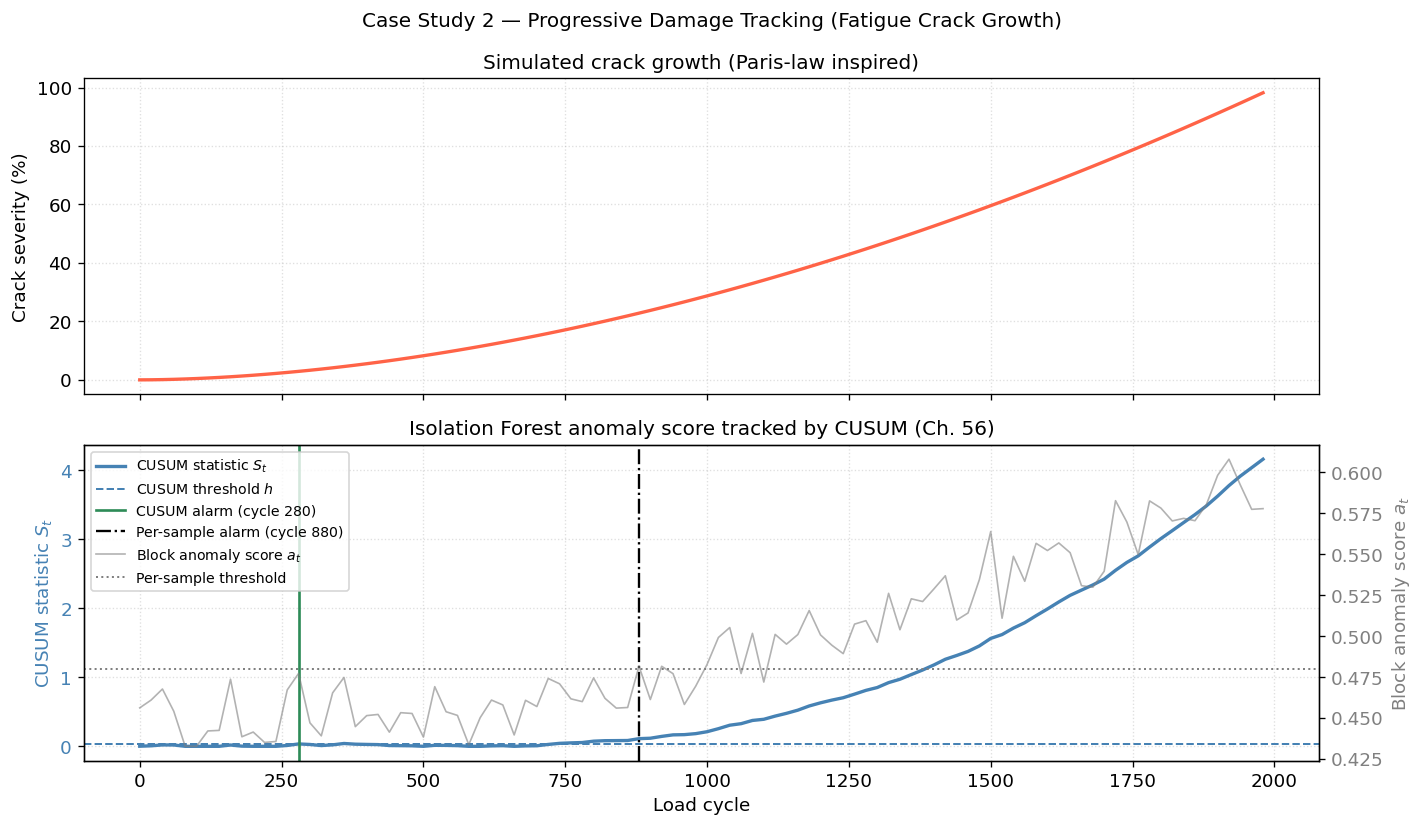

In [3]:
# ── Case Study 2: Progressive Damage Tracking with CUSUM ─────────────────────
# A fatigue crack grows over N_CYCLES load cycles. Every CYCLES_PER_BLOCK cycles
# we draw a block of strain readings from the current (partially shifted)
# distribution, score each with the Case-Study-1 Isolation Forest, and track the
# block's mean anomaly score a_t. Two detectors run on that stream:
#   * a per-sample (point-in-time) threshold, and
#   * the CUSUM statistic of Chapter 56 (Eq. 56.2), which accumulates evidence.
# For a gradual shift, CUSUM raises the alarm earlier than the point threshold.
np.random.seed(7)

N_CYCLES         = 2000     # total simulated load cycles
CYCLES_PER_BLOCK = 20       # strain readings per cycle-block
N_BLOCKS         = N_CYCLES // CYCLES_PER_BLOCK
GROWTH_EXPONENT  = 1.8      # Paris-law-flavoured acceleration of crack severity
N_CALIB_BLOCKS   = 300      # healthy blocks used to calibrate the detectors

mu_healthy = np.array(mean_healthy, dtype=float)
mu_damaged = np.array(mean_damaged, dtype=float)


def block_score(severity):
    """Mean Isolation Forest anomaly score for one block of strain readings.

    The block is drawn from a distribution interpolated between the healthy and
    fully-damaged states by ``severity`` in [0, 1]. ``iso`` and ``sc`` are reused
    from Case Study 1, so the detector is identical to the one evaluated there.
    """
    mu = mu_healthy + severity * (mu_damaged - mu_healthy)
    cov = (1 - severity) * cov_healthy + severity * cov_damaged
    block = np.random.multivariate_normal(mu, cov, CYCLES_PER_BLOCK)
    return np.mean(-iso.score_samples(sc.transform(block)))


def cusum(scores, baseline_mean, allowance):
    """One-sided CUSUM S_t = max(0, S_{t-1} + (a_t - mu0) - k)  (Ch. 56, Eq. 56.2)."""
    S = np.zeros(len(scores))
    running = 0.0
    for t, a_t in enumerate(scores):
        running = max(0.0, running + (a_t - baseline_mean) - allowance)
        S[t] = running
    return S


def first_crossing(series, threshold):
    """Index of the first element strictly above ``threshold``, else ``None``."""
    hits = np.flatnonzero(series > threshold)
    return int(hits[0]) if hits.size else None


# Calibrate both detectors on healthy blocks (severity = 0).
baseline = np.array([block_score(0.0) for _ in range(N_CALIB_BLOCKS)])
mu0, sigma0 = baseline.mean(), baseline.std()

POINT_FALSE_ALARM_PCT = 99.0     # per-sample threshold: ~1% false-alarm rate on healthy blocks
ALLOWANCE_SIGMA       = 0.4      # k = 0.4 sigma (roughly half the shift worth detecting)
THRESHOLD_SIGMA       = 2.5      # h, tuned for a low false-alarm rate on the baseline
point_threshold = np.percentile(baseline, POINT_FALSE_ALARM_PCT)
allowance = ALLOWANCE_SIGMA * sigma0
cusum_h   = THRESHOLD_SIGMA * sigma0

# Grow the crack and track the anomaly score block by block.
crack_severity = (np.arange(N_BLOCKS) / N_BLOCKS) ** GROWTH_EXPONENT
block_scores = np.array([block_score(s) for s in crack_severity])
cycle_axis = np.arange(N_BLOCKS) * CYCLES_PER_BLOCK

S = cusum(block_scores, mu0, allowance)
point_idx = first_crossing(block_scores, point_threshold)
cusum_idx = first_crossing(S, cusum_h)


def report(name, idx):
    """Print (and return) the alarm cycle for a detector, or None if it never fires."""
    if idx is None:
        print(f"{name:24s}: no alarm within the simulation window")
        return None
    cyc = int(cycle_axis[idx])
    print(f"{name:24s}: cycle {cyc:>4d}  (crack severity ~ {crack_severity[idx]*100:4.1f}%)")
    return cyc


point_cycle = report("Per-sample threshold", point_idx)
cusum_cycle = report("CUSUM", cusum_idx)
if point_cycle is not None and cusum_cycle is not None:
    print(f"CUSUM lead time: {point_cycle - cusum_cycle} cycles earlier")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle('Case Study 2 — Progressive Damage Tracking (Fatigue Crack Growth)', fontsize=12)

axes[0].plot(cycle_axis, crack_severity * 100, color='tomato', lw=2)
axes[0].set_ylabel('Crack severity (%)')
axes[0].set_title('Simulated crack growth (Paris-law inspired)')
axes[0].grid(True, linestyle=':', alpha=0.4)

ax = axes[1]
ax.plot(cycle_axis, S, color='steelblue', lw=2, label=r'CUSUM statistic $S_t$')
ax.axhline(cusum_h, color='steelblue', lw=1.2, ls='--', label=r'CUSUM threshold $h$')
ax.set_xlabel('Load cycle')
ax.set_ylabel(r'CUSUM statistic $S_t$', color='steelblue')
ax.tick_params(axis='y', labelcolor='steelblue')
ax.set_title('Isolation Forest anomaly score tracked by CUSUM (Ch. 56)')
ax.grid(True, linestyle=':', alpha=0.4)

# Raw block anomaly score and its point threshold live on a second axis (different scale).
ax2 = ax.twinx()
ax2.plot(cycle_axis, block_scores, color='gray', lw=1.0, alpha=0.6, label=r'Block anomaly score $a_t$')
ax2.axhline(point_threshold, color='gray', lw=1.2, ls=':', label='Per-sample threshold')
ax2.set_ylabel(r'Block anomaly score $a_t$', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

if cusum_idx is not None:
    ax.axvline(cusum_cycle, color='seagreen', lw=1.6, label=f'CUSUM alarm (cycle {cusum_cycle})')
if point_idx is not None:
    ax.axvline(point_cycle, color='black', lw=1.4, ls='-.', label=f'Per-sample alarm (cycle {point_cycle})')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8.5, loc='upper left')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig59_nb1_crack_growth_cusum.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 3 — Composite Damage-Type Classification: Distinguishing Four States

*(Illustrative simulation inspired by the composite-SHM literature, not a reproduction of a specific experiment.)*

Knowing that damage is present is only the first step; knowing *what kind* — and therefore what action to take — requires classification. The four classes represent composite damage modes with physically distinct strain signatures: matrix cracking distributes a small stiffness loss across channels with elevated variance; delamination decouples the through-thickness response, shifting channels 3 and 4; fiber breakage removes load-carrying capacity in the primary direction, dropping channels 1 and 2 sharply. Matrix cracking and delamination produce the most similar signatures and are the classes most often confused.

A random forest is trained on labeled data (200 samples per class, 75/25 split) and evaluated by confusion matrix, 5-fold cross-validation, and feature importance.


Random Forest  Test accuracy=0.795  5-fold CV accuracy=0.838


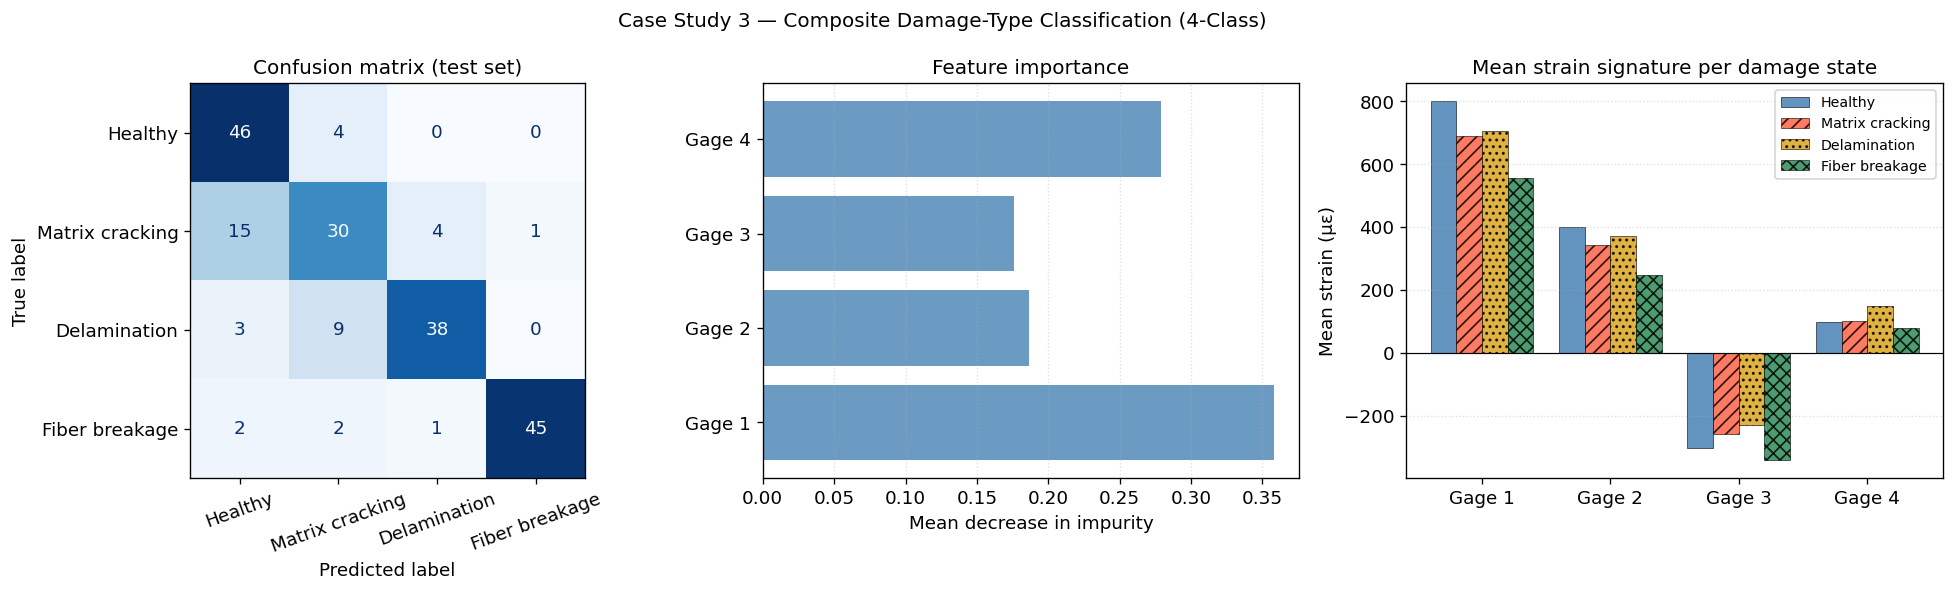

confusion (rows=true):
[[46  4  0  0]
 [15 30  4  1]
 [ 3  9 38  0]
 [ 2  2  1 45]]


In [4]:
# ── Case Study 3: Composite Damage-Type Classification ───────────────────────
# Four composite states, each leaving a distinct 4-channel strain signature:
#   0 - Healthy          baseline
#   1 - Matrix cracking  distributed micro-damage -> small proportional drop, variance up
#   2 - Delamination     through-thickness decoupling -> ch3 & ch4 shift (confusable w/ matrix)
#   3 - Fiber breakage   primary load path severed -> ch1 & ch2 drop sharply, redistribution
np.random.seed(21)

N_PER_CLASS = 200
TEST_SIZE   = 0.25
N_FOLDS     = 5

# Covariances per state (µε^2). Matrix cracking inflates the healthy covariance;
# delamination has its own through-thickness structure.
cov_matrix = (1.2 * cov_healthy).tolist()
cov_delam  = [[2600, 700, -500, 250], [700, 1700, -350, 150],
              [-500, -350, 3200, -450], [250, 150, -450, 900]]
states = {
    'Healthy':         (mean_healthy,          cov_healthy),
    'Matrix cracking': ([690, 345, -258, 102], cov_matrix),
    'Delamination':    ([706, 372, -228, 150], cov_delam),
    'Fiber breakage':  ([558, 250, -340,  80], cov_damaged),
}

X_parts, y_parts = [], []
for label, (name, (mu, cov)) in enumerate(states.items()):
    X_parts.append(np.random.multivariate_normal(mu, cov, N_PER_CLASS))
    y_parts.append(np.full(N_PER_CLASS, label))

X_cls = np.vstack(X_parts); y_cls = np.concatenate(y_parts)
class_names = list(states.keys())

X_tr, X_te, y_tr, y_te = train_test_split(X_cls, y_cls, test_size=TEST_SIZE,
                                          stratify=y_cls, random_state=RANDOM_STATE)
clf = RandomForestClassifier(n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE).fit(X_tr, y_tr)
cv_acc = cross_val_score(clf, X_cls, y_cls, cv=N_FOLDS).mean()
test_acc = clf.score(X_te, y_te)
print(f"Random Forest  Test accuracy={test_acc:.3f}  {N_FOLDS}-fold CV accuracy={cv_acc:.3f}")

cm = confusion_matrix(y_te, clf.predict(X_te))
importances = clf.feature_importances_
channel_names = ['Gage 1', 'Gage 2', 'Gage 3', 'Gage 4']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Case Study 3 — Composite Damage-Type Classification (4-Class)', fontsize=12)

disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion matrix (test set)')
axes[0].tick_params(axis='x', labelrotation=20)

axes[1].barh(channel_names, importances, color='steelblue', alpha=0.8)
axes[1].set_xlabel('Mean decrease in impurity')
axes[1].set_title('Feature importance')
axes[1].grid(True, axis='x', linestyle=':', alpha=0.4)

ax = axes[2]; x = np.arange(4); width = 0.2
colors = ['steelblue', 'tomato', 'goldenrod', 'seagreen']
hatches = ['', '///', '...', 'xxx']  # per-series hatch -> separable in B&W
for i, (name, (mu, _)) in enumerate(states.items()):
    ax.bar(x + i * width, mu, width, label=name, color=colors[i], alpha=0.85,
           edgecolor='black', linewidth=0.4, hatch=hatches[i])
ax.set_xticks(x + 1.5 * width); ax.set_xticklabels(channel_names)
ax.set_ylabel('Mean strain (µε)'); ax.set_title('Mean strain signature per damage state')
ax.legend(fontsize=8.5); ax.grid(True, axis='y', linestyle=':', alpha=0.4)
ax.axhline(0, color='black', lw=0.7)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig59_nb1_damage_classification.png', bbox_inches='tight', dpi=150)
plt.show()
print('confusion (rows=true):'); print(cm)

---
## Where to Take This Next

These three case studies are deliberately minimal starting points. A few concrete extensions turn them into something closer to a real monitoring pipeline:

1. **Tune the CUSUM operating point against a false-alarm budget.** In Case Study 2 the allowance $k$ and threshold $h$ are set by hand. Sweep them, and for each pair measure the *average run length* to a false alarm on a long healthy stream against the detection lead time on the crack-growth stream. Plotting lead time versus false-alarm rate reproduces the Neyman–Pearson trade-off of Chapter 56 and lets you pick $h$ for a stated "one false alarm per year" target.

2. **Replace the point-in-time detector with a physics-grounded feature.** All three studies feed raw channel strains to the model. Try instead the *ratios* between gages (which cancel a common-mode load change) or a PCA reconstruction error (Chapter 55), and see whether the composite classes in Case Study 3 separate more cleanly — especially the matrix-cracking versus delamination pair that the confusion matrix shows is hardest to call.

3. **Stress-test the classifier under distribution shift.** Retrain Case Study 3, then evaluate it on strain data generated with a shifted temperature offset or a different load amplitude than it was trained on. The accuracy drop is a direct, quantitative demonstration of the "operating domain" caveat this chapter insists every ML-with-strain result must report.